In [1]:
import os, sys
sys.path.append('../neural_model_identification')
os.getcwd()

'/home/dema/Project/simple_neural_mpc/dev_notebook'

In [2]:
from Agent.AbstractLearner import AbstractLearner
from Agent.PINN_uniKin_Learner import PINNLearner
from Agent.neural_nets.MLP import MLP

from Agent.dyn_utils.utils import (
    euler_integration,
    normalize_state,
    denormalize_state
)
from parameters.train_params import TrainParams
from data_module.preprocess import DataPreProcess

import numpy as np
import torch 
from torch.func import jacrev
from torch.func import vmap

from typing import Tuple
import matplotlib.pyplot as plt

In [139]:
path = "../neural_model_identification/data_module/trajectories_kin/"
ACT, STAT = [], []
demo_len = []
for i in range(10):
    actions = np.load(path + f"sample_{i}/actions.npy")
    states = np.load(path + f"sample_{i}/states.npy")
    demo_len.append(states.shape[0])
    ACT.append(actions)
    STAT.append(states)
#actions = np.load(path + "sample_0/actions.npy")
#states = np.load(path + "sample_0/states.npy")
actions = np.vstack(ACT)
states = np.vstack(STAT)

states.shape, actions.shape

((10010, 3), (10000, 2))

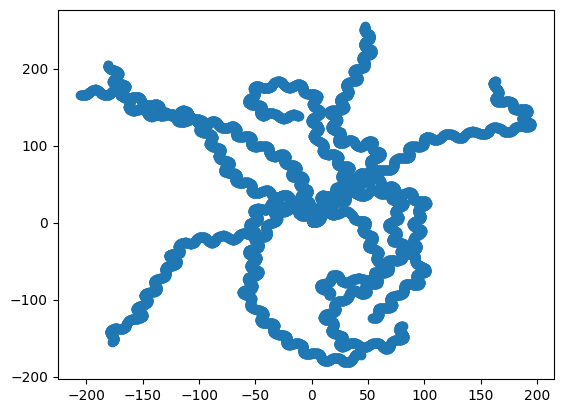

In [140]:
plt.scatter(states[:, 0], states[:, 1])
#plt.scatter(actions[:, 0], actions[:, 1])

In [141]:
states.max(0)

array([194.76458797, 254.68538601,   7.56255014])

In [142]:
#states = normalize_state(states, x_max=states.max(0), x_min=states.min(0))
#actions = normalize_state(actions, x_max=actions.max(0), x_min=actions.min(0))

In [143]:
params = TrainParams()

In [144]:
# X-0 [state(0)_i, action_const, t=0] (init state, time 0, const input ) --> Y0 = [init state]   
# X-1 [state(0)_i, action_const, t=T] (init state, time T, const input ) --> Y1 = [next state]

X, Y = [], []


delta_t = 0.3
for demo in range(len(demo_len)):
    for i in range(demo_len[demo] - 1):
        x0 = np.hstack((states[i, :], actions[i], 0))
        y0 = states[i, :]

        x1 = np.hstack((states[i, :], actions[i], 0.3))
        y1 = states[i+1, :]

        X.append(torch.FloatTensor(x0))
        X.append(torch.FloatTensor(x1))
        Y.append(torch.FloatTensor(y0))
        Y.append(torch.FloatTensor(y1))



dataset_tensor = torch.hstack((torch.vstack(X), torch.vstack(Y)))

In [145]:
states_range = (states.max(0), states.min(0))
actions_range = (actions.max(0), actions.min(0))


In [238]:
class PINNLearnerDEMA(AbstractLearner):

    def __init__(self,
                 data_tensor: torch.Tensor,
                 max_min_states: Tuple, 
                 max_min_actions: Tuple, 
                 delta_t = 0.3,
                 device='cpu'):
        super(AbstractLearner, self).__init__()
        
        self.device = device
        self.demos = data_tensor.to(self.device)
        self.batch_size = 512

        self.state_dim = 3
        self.action_dim = 2

        self.states_max= torch.FloatTensor(max_min_states[0]).to(self.device)
        self.states_min = torch.FloatTensor(max_min_states[1]).to(self.device)

        self.actions_max = torch.FloatTensor(max_min_actions[0]).to(self.device)
        self.actions_min = torch.FloatTensor(max_min_actions[1]).to(self.device)

        self.delta_t = delta_t

        self.n_demos = len(data_tensor)
        self.input_dim = self.state_dim + self.action_dim + 1

        self.model = MLP(
            state_dim=self.state_dim,
            input_dim=self.action_dim,
            n_hidden_layer=3, 
            latent_dim=120, 
            time=True,
        ).to(self.device)

        self.imit_weight = 1
        self.physic_weight = 1
        self.boundary_weight = 1

        self.mse_loss = torch.nn.MSELoss()
        
        
        
        self.optimizer_adam = torch.optim.Adam(
            self.model.parameters(),
            lr=0.001,
            weight_decay=0.00001,
            )
        
        
        self.optimizer_LBFGS = torch.optim.LBFGS(
            self.model.parameters(),
            lr=0.9,
            history_size=30,
            max_iter=6,
            line_search_fn='strong_wolfe',
            )
        self.optimizer_type = None
        
    
    def normalize(self, x, x_min, x_max):
        return (x_max - x_min) *x + x_min
        

    def calc_loss(self, sample):

        tot_loss = 0
        stats = {}
        # 1) imit loss --> this encapsulate the boundary condition
        if self.imit_weight != 0:
            
            X_imit, y_imit = sample[:, :self.input_dim], sample[:, self.input_dim:]
            y_hat = self.model(X_imit)

            imit_loss = self.mse_loss(y_imit, y_hat) * self.imit_weight
            tot_loss += imit_loss
            stats['imit'] = imit_loss.item()

        # sampling are down here
        sample_batch_size = 2028

        # 2) physics loss --> use derivative respect time  
        if self.physic_weight != 0:
            
            # element for the loss allocation
            grad_stock = torch.zeros((sample_batch_size, self.state_dim), device=self.device)
            f = torch.zeros((sample_batch_size, self.state_dim), device=self.device) 

            # sample state, action, time
            state = torch.randn(sample_batch_size, self.state_dim, device=self.device)
            action = torch.randn(sample_batch_size, self.action_dim, device=self.device)
            t = torch.rand(sample_batch_size, 1, device=self.device)

            # normalize in the training range
            # actual range is -1, 1 but let see if some scaling can help
            state = self.normalize(state, self.states_min, self.states_max)
            # state = self.normalize(state, self.states_min, self.states_max) 
            action = self.normalize(action, self.actions_min, self.actions_max)
            t = self.normalize(t, 0, self.delta_t)

            # create input vect
            X_physic = torch.hstack((state, action, t))
            X_physic.requires_grad = True

            # calc derivative --> vmap is used to vectorize the jacobian calculation
            #                 --> jacrev is used to calculate the jacobian of the model
            jac = vmap(jacrev(self.model))(X_physic)

            # jac is a 3x6, last column is the derivative respect time
            # jac = [batch, row=3, col=6]
            grad_stock = jac[:, :, -1]

            # physic model
            f[:, 0] = torch.cos(X_physic[:, 2])*X_physic[:, 3]
            f[:, 1] = torch.sin(X_physic[:, 2])*X_physic[:, 3]
            f[:, 2] = X_physic[:, 4]

            # calc cost 
            cost = ((grad_stock - f)**2).mean() * self.physic_weight
            
            # add logs
            tot_loss +=  cost
            stats['physic'] = cost.item()
        

        # boundary loss : 
        if self.boundary_weight != 0:
            # our boundary condition : any times that the velocity is zero, the state must stay at rest

            # sample state, time. Action is zero
            state = torch.randn(sample_batch_size, self.state_dim, device=self.device)
            action = torch.zeros(sample_batch_size, self.action_dim, device=self.device)
            t = torch.rand(sample_batch_size, 1, device=self.device)
            
            # actual range is -1, 1 but let see if some scaling can help
            state = self.normalize(state, self.states_min, self.states_max) 
            # state = self.normalize(state, self.states_min, self.states_max) 
            # action must be zero
            t = self.normalize(t, 0, self.delta_t)

            # target of the model for this: the same as the input
            Y_BC = state.clone()

            X_BC = torch.hstack((state, action, t))
            X_BC.requires_grad = True

            # calc the prediction
            y_hat_BC = self.model(X_BC)

            # mse loss
            BC_loss = self.mse_loss(y_hat_BC, Y_BC) * self.boundary_weight

            # add logs
            tot_loss += BC_loss
            stats['BC'] = BC_loss.item()



        stats['tot'] = tot_loss.item()

        return tot_loss, stats
    
    def train_step(self):
        # adam
        # ------------
        if self.optimizer_type == 'adam':
            sample = self.sample_data() 
            loss, stats = self.calc_loss(sample)
            self.update_model(loss)
            return loss, stats
        elif self.optimizer_type == 'LBFGS':
            self.optimizer = self.optimizer_LBFGS
            loss = self.update_model(None)
            return loss
        else:
            raise("optimizer not found")
        
    def sample_data(self):
        idx = torch.randperm(self.demos.shape[0])
        return self.demos[idx]
    
    def closure(self):
        self.optimizer.zero_grad()
        loss = self.calc_loss(self.sample_data())[0]
        loss.backward()
        return loss


    def update_model(self, loss):
        # adam: 
        # -----------
        if self.optimizer_type == 'adam':
            self.optimizer_adam.zero_grad()
            loss.backward()
            self.optimizer_adam.step()
        
        elif self.optimizer_type == 'LBFGS':
            loss = self.optimizer_LBFGS.step(self.closure)
            return loss
        else:
            raise("optimizer not found")
        
    def propagate(self, input_tensor):
        # no euler integration in this learner 
        x_next = self.model(input_tensor)
        return x_next


In [239]:
learner = PINNLearnerDEMA(dataset_tensor,
                          states_range,
                          actions_range,
                          delta_t=0.3,
                          device='cuda')

learner.physic_weight = 1
learner.boundary_weight = 1
learner.imit_weight = 1

j_adam = 0
j_LFGBS = 0

In [244]:
# tot 6k
learner.optimizer_type = 'adam'
for i in range(3000):
    j_adam += 1
    loss, stats = learner.train_step()
    #loss = learner.train_step()
    s = ""
    if (i%10 == 0):
        for item, k in stats.items():
            s += f"{item}: {k} ; "
        print(f"iter: (Adam/LGFVD) {j_adam}, {j_LFGBS} : {s}")            
        #print(f"iter: {j}, loss: {loss.item()}")

iter: (Adam/LGFVD) 12001, 0 : imit: 1.0869293212890625 ; physic: 32.45952606201172 ; BC: 3304.826904296875 ; tot: 3338.373291015625 ; 
iter: (Adam/LGFVD) 12011, 0 : imit: 2.5883615016937256 ; physic: 32.818389892578125 ; BC: 3499.908203125 ; tot: 3535.31494140625 ; 
iter: (Adam/LGFVD) 12021, 0 : imit: 2.078608989715576 ; physic: 34.42329025268555 ; BC: 3155.896240234375 ; tot: 3192.398193359375 ; 
iter: (Adam/LGFVD) 12031, 0 : imit: 2.597316026687622 ; physic: 33.285465240478516 ; BC: 2820.924072265625 ; tot: 2856.806884765625 ; 
iter: (Adam/LGFVD) 12041, 0 : imit: 1.5232961177825928 ; physic: 32.72888946533203 ; BC: 4038.850830078125 ; tot: 4073.10302734375 ; 
iter: (Adam/LGFVD) 12051, 0 : imit: 1.6988533735275269 ; physic: 33.4455451965332 ; BC: 3958.591796875 ; tot: 3993.736083984375 ; 
iter: (Adam/LGFVD) 12061, 0 : imit: 2.49692702293396 ; physic: 32.83694076538086 ; BC: 3262.412353515625 ; tot: 3297.746337890625 ; 
iter: (Adam/LGFVD) 12071, 0 : imit: 3.75606107711792 ; physic: 34.

In [235]:
learner.optimizer_type = 'LBFGS'
for i in range(500):
    j_LFGBS += 1
    loss = learner.train_step()
    s = ""
    if (i%10 == 0):     
        print(f"iter: (adam/LGFBS) {j_adam}, {j_LFGBS}, loss: {loss.item()}")

iter: (adam/LGFBS) 30000, 1, loss: 229.31394958496094
iter: (adam/LGFBS) 30000, 11, loss: 217.34036254882812
iter: (adam/LGFBS) 30000, 21, loss: 159.2237091064453
iter: (adam/LGFBS) 30000, 31, loss: 153.23019409179688
iter: (adam/LGFBS) 30000, 41, loss: 36.665771484375
iter: (adam/LGFBS) 30000, 51, loss: 209.39349365234375
iter: (adam/LGFBS) 30000, 61, loss: 189.71359252929688
iter: (adam/LGFBS) 30000, 71, loss: 118.22343444824219
iter: (adam/LGFBS) 30000, 81, loss: 37.332244873046875
iter: (adam/LGFBS) 30000, 91, loss: 29.427616119384766
iter: (adam/LGFBS) 30000, 101, loss: 137.15174865722656
iter: (adam/LGFBS) 30000, 111, loss: 64.31612396240234
iter: (adam/LGFBS) 30000, 121, loss: 150.78579711914062
iter: (adam/LGFBS) 30000, 131, loss: 57.188575744628906
iter: (adam/LGFBS) 30000, 141, loss: 102.91289520263672
iter: (adam/LGFBS) 30000, 151, loss: 92.33528900146484
iter: (adam/LGFBS) 30000, 161, loss: 115.04315185546875
iter: (adam/LGFBS) 30000, 171, loss: 46.064125061035156
iter: (ad

In [135]:
demo_len

[1001, 1001, 1001, 1001, 1001, 1001, 1001, 1001, 1001, 1001]

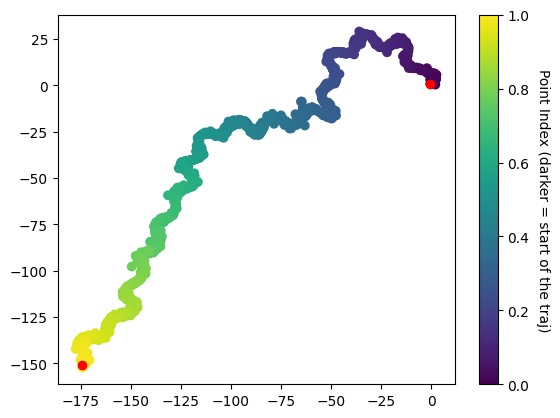

In [246]:

x_0 = torch.FloatTensor(states[0, :]).to('cuda')
a_0 = torch.FloatTensor(actions[0, :]).to('cuda')
t = torch.FloatTensor([0.3]).to('cuda')
pair = torch.hstack((x_0, a_0, t)).unsqueeze(0)
#pair = torch.hstack((x_0, a_0)).unsqueeze(0)
zero = torch.FloatTensor([0]).to('cuda')

traj_generated = []
id_demo = 1
for i in range((id_demo-1)*demo_len[id_demo], id_demo*demo_len[id_demo]-1):
    with torch.no_grad():
        
        x_i = learner.model(pair).squeeze()
        pair = torch.hstack((
            #x_i,
            torch.FloatTensor(states[i, :]).to('cuda'), 
            torch.FloatTensor(actions[i, :]).to('cuda'),
            t
        )).unsqueeze(0).to('cuda')
        traj_generated.append(x_i.detach().cpu().numpy())


traj = np.array(traj_generated)

color_id = np.linspace(0, 1, len(traj))
cmap = plt.get_cmap('viridis')
colors = cmap(color_id)

scatter = plt.scatter(traj[:, 0], traj[:, 1], color=colors)
plt.scatter(traj[0, 0], traj[0, 1], color='red')
plt.scatter(traj[-1, 0], traj[-1, 1], color='red')

cbar = plt.colorbar(scatter)
cbar.set_label("Point Index (darker = start of the traj)", rotation=270, labelpad=15)


#plt.scatter(states[:, 0], states[:, 1], color='blue')
#plt.scatter(states[0, 0], states[0, 1], color='black')
#plt.scatter(states[-1, 0], states[-1, 1], color='white')



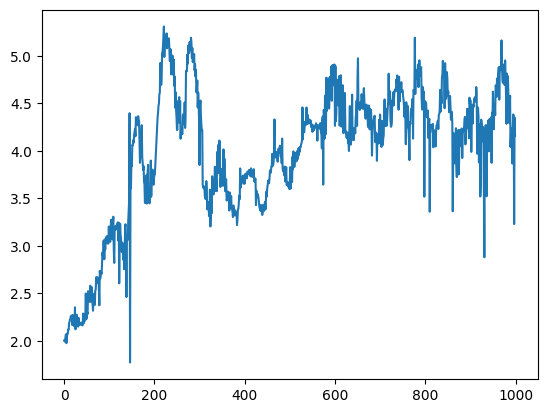

In [233]:
plt.plot(traj[:, -1])

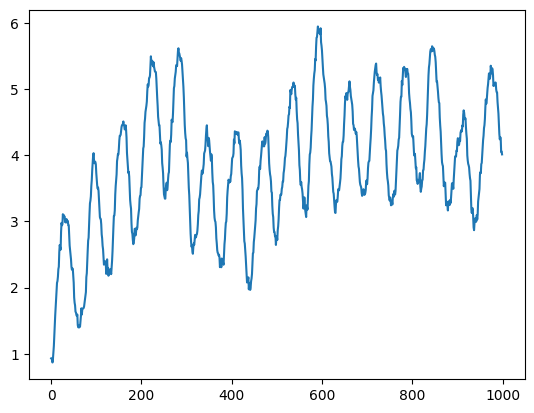

In [213]:
plt.plot(states[:1000,-1])